<a href="https://colab.research.google.com/github/vicky5859/computer-vison-/blob/main/EX%3A15%20Perform%20transformation%20using%20Direct%20Linear%20Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-08-05 131516.png to Screenshot 2026-08-05 131516.png
DLT Homography Matrix:
[[ 8.94803321e-01 -5.97614403e-02  5.00000000e+01]
 [ 4.27942987e-02  7.25754273e-01  3.00000000e+01]
 [ 2.00148269e-04 -3.41882995e-04  1.00000000e+00]]


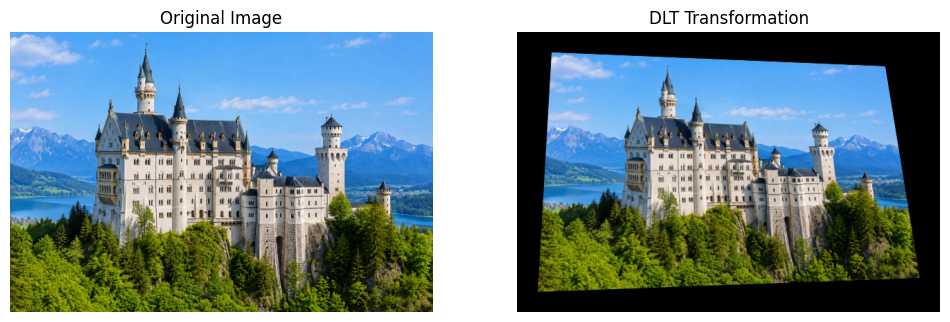

In [2]:
# EXPERIMENT 15
# Transformation using Direct Linear Transformation (DLT)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename)

if img is None:
    print("Error: Image not found")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    # Source points
    src = np.float32([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1]
    ])

    # Destination points
    dst = np.float32([
        [50, 30],
        [w - 80, 50],
        [w - 30, h - 50],
        [30, h - 30]
    ])

    # Construct matrix A for DLT
    A = []

    for (x, y), (u, v) in zip(src, dst):
        A.append([
            -x, -y, -1,
            0, 0, 0,
            u*x, u*y, u
        ])

        A.append([
            0, 0, 0,
            -x, -y, -1,
            v*x, v*y, v
        ])

    A = np.array(A)

    # Singular Value Decomposition
    U, S, Vt = np.linalg.svd(A)

    # Last row of Vt gives solution
    H = Vt[-1].reshape(3, 3)

    # Normalize
    H = H / H[2, 2]

    print("DLT Homography Matrix:")
    print(H)

    # Apply transformation
    result = cv2.warpPerspective(img, H, (w, h))

    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # Display
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result_rgb)
    plt.title("DLT Transformation")
    plt.axis("off")

    plt.show()